# Entrenamiento de Modelos

Como ya hemos explicado en la investigación, lo que nosotros haremos será entrenar diferentes modelos haciendo uso de los datos de entrenamiento. En este notebook haremos crearemos modelos que hagan uso de los datos extraídos usando técnicas MFCC con preprocesamiento básico. De este modo, seguiremos el flujo básico de entrenamiento de modelos de ML:

1. Preprocesado de Datos. Esta parte ya fue realizada de manera previa con código python. En este caso, fue preprocesamiento básico.
2. Selección y Entrenamiento de Modelo.
    * Elegir algoritmo
    * Entrenar hiperparámetros
3. Evaluación de Resultados y Ajuste
4. Evaluación Final

## MFCC

In [ ]:
import pickle
import numpy as np
import pandas as pd
import mlflow
import os
import joblib

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.base import clone

#Modelos
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_auc_score, roc_curve, auc, classification_report)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit

In [3]:
#Cargamos base de datos de mlflow
mlflow.set_tracking_uri("sqlite:///../resultados/resultados_voces.db")
mlflow.set_experiment("Clasificacion_Modelos_Clasicos_Notebooks")

2026/05/24 11:46:27 INFO mlflow.tracking.fluent: Experiment with name 'Clasificacion_Modelos_Clasicos_Notebooks' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/pedro/git/InvestigacionFinGrado/notebooks/mlruns/2', creation_time=1779615987942, experiment_id='2', last_update_time=1779615987942, lifecycle_stage='active', name='Clasificacion_Modelos_Clasicos_Notebooks', tags={}, trace_location=None, workspace='default'>

In [6]:
#Cargamos dataset de MFCC con Pickle
ruta_train = '../datos_entrenamiento/train_mfcc_basico1.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_basico1.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

#Vamos a ver la información de nuestros datasets.
print("Forma del Dataset de entrenamiento:",df_train.shape)
print()
print("Encontrar datos nulos ---> ",df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:",df_test.shape)
print()
print("Encontrar datos nulos ---> ",df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (66, 5)

Encontrar datos nulos --->  nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (18, 5)

Encontrar datos nulos --->  nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


In [8]:
df_train.head()

,nombre_archivo,mfccs,caja_toracica,grupo,fold
0,Asma con CPAP urgencias.m4a,"[[-661.04315, -661.04315, -661.04315, -661.043...",Obstructivo,Ventilación Invasiva,3
1,Nueva grabación 35.m4a,"[[-662.22363, -662.22363, -662.22363, -662.223...",Mixto,Oxigeno Bajo Flujo,1
2,Nueva grabación 38.m4a,"[[-620.70154, -620.70154, -620.70154, -620.701...",Mixto,Oxigeno Bajo Flujo,4
3,Nueva grabación 51.m4a,"[[-643.0202, -643.0202, -643.0202, -643.0202, ...",Mixto,Oxigeno Bajo Flujo,2
4,Nueva grabación 59.m4a,"[[-658.14215, -658.14215, -658.14215, -658.142...",Mixto,Oxigeno Bajo Flujo,3


Ahora, como se trata de un preprocesado básico, no hemos aplicado de manera previa ninguna forma de normalización de duración, Chunking o segmentación de datos. Esto representa un problema relevante, ya que los audios de entrada no tienen todos la misma longitud.

Este aspecto es crítico porque, debido a la naturaleza del algoritmo MFCC, el número de coeficientes extraídos depende directamente de la duración del audio. En consecuencia, cada muestra del conjunto de datos puede presentar un número diferente de características, lo que genera vectores de longitud variable.
Este comportamiento es incompatible con modelos de aprendizaje automático clásicos como SVM (Support Vector Machine) o RF (Random Forest), los cuales requieren que todas las muestras del conjunto de datos tengan exactamente la misma dimensionalidad de entrada. 

Por lo tanto, antes de alimentar los datos a cualquiera de estos modelos, será necesario aplicar alguna estrategia de homogeneización de la longitud de las secuencias. En este caso aplicaremos Aplanamiento o Pooling de datos. Sabemos que esto puede conllevar perdida de datos, sin embargo, es algo necesario en el caso de este preprocesamiento.

Nosotros estamos probando distintas opciones para compararlas entre ellas.

### Preprocesado MFCC

In [12]:
#Aplicamos el Pooling.
#Calculamos la media y la desviación de cada matriz mfcc sobre el eje=1 (tiempo)
medias_train = df_train['mfccs'].apply(lambda x: np.mean(x, axis=1))
desviaciones_train = df_train['mfccs'].apply(lambda x: np.std(x, axis=1))

medias_test = df_test['mfccs'].apply(lambda x: np.mean(x, axis=1))
desviaciones_test = df_test['mfccs'].apply(lambda x: np.std(x, axis=1))

#Las pasamos a dataframes distintos:
columnas_media = [f'mfcc_media_{i+1}' for i in range(30)]
columnas_std = [f'mfcc_std_{i+1}' for i in range(30)]
df_medias_train = pd.DataFrame(medias_train.tolist(), columns=columnas_media)
df_stds_train = pd.DataFrame(desviaciones_train.tolist(), columns=columnas_std)
df_medias_test = pd.DataFrame(medias_test.tolist(), columns=columnas_media)
df_stds_test = pd.DataFrame(desviaciones_test.tolist(), columns=columnas_std)

#Recuperamos datos originales:
df_metadatos_train = df_train[['nombre_archivo', 'caja_toracica', 'grupo', 'fold']]
df_metadatos_test = df_test[['nombre_archivo', 'caja_toracica', 'grupo', 'fold']]

#Construimos los dataframes aplanados o planos (aplicando Pooling global)
df_train_plano = pd.concat([df_metadatos_train, df_medias_train, df_stds_train], axis=1)
df_test_plano = pd.concat([df_metadatos_test, df_medias_test, df_stds_test], axis=1)

print(df_train_plano.shape)
print(df_test_plano.shape)
df_train_plano.head()

(66, 64)
(18, 64)


,nombre_archivo,caja_toracica,grupo,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_21,mfcc_std_22,mfcc_std_23,mfcc_std_24,mfcc_std_25,mfcc_std_26,mfcc_std_27,mfcc_std_28,mfcc_std_29,mfcc_std_30
0,Asma con CPAP urgencias.m4a,Obstructivo,Ventilación Invasiva,3,-375.897003,129.544800,5.386030,28.277493,4.883600,-5.609246,...,8.101558,7.840837,7.681446,7.548085,7.635071,7.681962,7.488742,7.176179,7.508937,6.967589
1,Nueva grabación 35.m4a,Mixto,Oxigeno Bajo Flujo,1,-407.721252,148.712952,12.665081,17.320671,-4.951169,-8.668799,...,7.539688,8.012339,7.491555,7.423116,8.103828,7.788549,8.002262,7.971945,8.029599,7.895774
2,Nueva grabación 38.m4a,Mixto,Oxigeno Bajo Flujo,4,-389.588562,127.383217,7.405790,12.091285,-0.078286,-14.265192,...,7.482104,7.517180,8.282817,8.222688,8.523972,8.697010,8.187547,8.513536,9.315290,9.787004
3,Nueva grabación 51.m4a,Mixto,Oxigeno Bajo Flujo,2,-361.051758,127.392883,-14.025468,26.566433,-8.165603,-5.169389,...,8.146959,8.029797,7.952549,8.283257,9.081783,9.270673,9.248858,9.613788,9.655385,9.513621
4,Nueva grabación 59.m4a,Mixto,Oxigeno Bajo Flujo,3,-365.601501,116.383675,-2.508590,26.406342,-9.427022,-8.492299,...,8.251837,7.831652,8.330658,8.642197,8.555679,8.378823,8.720793,8.813965,9.157085,8.572627


Ahora, en nuestro dataset para cada entrada 64 características asignadas, de las cuales podemos extraer las 4 primeras que hacen referencia al nombre del archivo y sus clasificaciones, además del fold al que pertenecerían, que no son necesarios para las técnicas de reducción de características que vamos a aplicar, siendo estas matrices de correlación, mapas de calor y PCA. 

Estas técnicas las aplicamos ya que lo más seguro es que los valores generados al aplicar el proceso de Pooling por media y std estén muy correlacionados entre sí.

Hay que tener en cuenta que la reducción de características las hacemos en base del conjunto de datos de entrenamiento y luego lo aplicamos a los datos de test también.

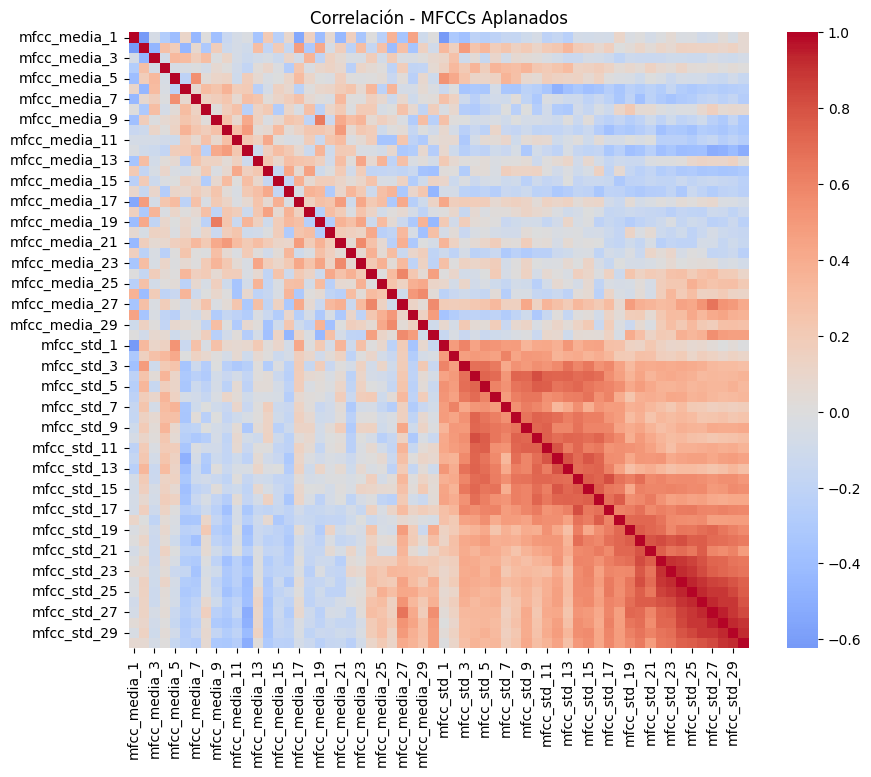

In [15]:
columnas_a_quitar = ['nombre_archivo', 'caja_toracica', 'grupo', 'fold']

X_train = df_train_plano.drop(columns=columnas_a_quitar)

#Calculamos la matriz de correlación
corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train,"MFCCs Aplanados")

Podemos observar como los últimos valores de desviación estándar presentan una elevada correlación positiva entre sí. De los demás coeficientes realmente no podemos decir gran cosa, ya que estos caen en valores intermedios, por lo que realmente no podemos descartar ninguno de ellos. Trabajaremos en la reducción de los mfcc_std_21 hasta mfcc_std_30.

En el caso de que observemos que encontramos varios valores de correlación entre features elevados, lo que podemos hacer es en sí aplicar tanto reducción manual de predictores como PCA. PCA recordar que nos permite en sí calcular, en base de un conjunto de predictores, otras features nuevas que son las más representativas. 
De este modo, eliminamos primero la redundancia más evidente y luego PCA puede extraer otro patrones más sutiles en un conjunto de predictores de menor tamaño.

In [18]:
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(21, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_22 y mfcc_std_21 -> Correlación: 0.748
mfcc_std_23 y mfcc_std_21 -> Correlación: 0.668
mfcc_std_23 y mfcc_std_22 -> Correlación: 0.907
mfcc_std_24 y mfcc_std_21 -> Correlación: 0.700
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.889
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.922
mfcc_std_25 y mfcc_std_21 -> Correlación: 0.648
mfcc_std_25 y mfcc_std_22 -> Correlación: 0.852
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.886
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.940
mfcc_std_26 y mfcc_std_21 -> Correlación: 0.757
mfcc_std_26 y mfcc_std_22 -> Correlación: 0.798
mfcc_std_26 y mfcc_std_23 -> Correlación: 0.827
mfcc_std_26 y mfcc_std_24 -> Correlación: 0.902
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.931
mfcc_std_27 y mfcc_std_21 -> Correlación: 0.593
mfcc_std_27 y mfcc_std_22 -> Correlación: 0.728
mfcc_std_27 y mfcc_std_23 -> Correlación: 0.751
mfcc_std_27 y mfcc_std_24 -> Correlación: 0.854
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.888
mfcc_std_27 y mfcc_std_26 -> Correlación

Aqui podemos observar todos los valores de correlación, donde observamos valores máximos de más 0.9 y otro valores que entran más en valores de correlación intermedios que podemos descartar.

Lo que haremos ahora será aplicar reducción en base de un umbral. Este umbral será 0.85.

In [21]:
umbral = 0.85
pares_a_eliminar = set()

for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        if abs(matriz_corr_sub.iloc[i, j]) > umbral:
            col1 = matriz_corr_sub.columns[i]
            col2 = matriz_corr_sub.columns[j]
            correlacion = matriz_corr_sub.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

#Las eliminamos:
X_MFCC_reducido = df_train_plano.drop(columns = pares_a_eliminar)
X_MFCC_reducido_test = df_test_plano.drop(columns = pares_a_eliminar)

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.907
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.889
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.922
mfcc_std_25 y mfcc_std_22 -> Correlación: 0.852
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.886
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.940
mfcc_std_26 y mfcc_std_24 -> Correlación: 0.902
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.931
mfcc_std_27 y mfcc_std_24 -> Correlación: 0.854
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.888
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.924
mfcc_std_28 y mfcc_std_25 -> Correlación: 0.891
mfcc_std_28 y mfcc_std_26 -> Correlación: 0.898
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.948
mfcc_std_29 y mfcc_std_26 -> Correlación: 0.897
mfcc_std_29 y mfcc_std_27 -> Correlación: 0.891
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.935
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.902
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.920
Columnas a eliminar: 
['mfcc_std_23', 'mfcc_std_24', 'mfcc_std_26', 'mfcc_std_30', 'mfcc

In [23]:
X_MFCC_reducido.head()

,nombre_archivo,caja_toracica,grupo,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_13,mfcc_std_14,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22
0,Asma con CPAP urgencias.m4a,Obstructivo,Ventilación Invasiva,3,-375.897003,129.544800,5.386030,28.277493,4.883600,-5.609246,...,9.473640,8.686655,8.706355,8.624832,8.205484,8.029873,7.684639,7.744459,8.101558,7.840837
1,Nueva grabación 35.m4a,Mixto,Oxigeno Bajo Flujo,1,-407.721252,148.712952,12.665081,17.320671,-4.951169,-8.668799,...,10.152788,8.990629,8.956245,9.023715,8.474727,7.665009,7.658316,7.713362,7.539688,8.012339
2,Nueva grabación 38.m4a,Mixto,Oxigeno Bajo Flujo,4,-389.588562,127.383217,7.405790,12.091285,-0.078286,-14.265192,...,9.322911,9.161196,9.738835,8.499793,8.431950,8.107263,8.096610,7.831814,7.482104,7.517180
3,Nueva grabación 51.m4a,Mixto,Oxigeno Bajo Flujo,2,-361.051758,127.392883,-14.025468,26.566433,-8.165603,-5.169389,...,9.026030,9.042562,8.658172,8.668781,8.808024,8.128394,8.380845,8.065220,8.146959,8.029797
4,Nueva grabación 59.m4a,Mixto,Oxigeno Bajo Flujo,3,-365.601501,116.383675,-2.508590,26.406342,-9.427022,-8.492299,...,8.758101,8.749906,9.047009,8.420721,8.043694,7.898134,7.806643,7.994286,8.251837,7.831652


In [25]:
X_MFCC_reducido_test.head()

,nombre_archivo,caja_toracica,grupo,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_13,mfcc_std_14,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22
0,Asma obesidad grave vni planta.m4a,Obstructivo,Ventilación Invasiva,-1,-369.902527,131.133347,-1.583405,9.456347,-13.103008,3.367258,...,8.591416,8.392600,7.566867,7.639826,7.565162,7.662803,7.490688,7.763735,7.250230,7.355145
1,Epoc como respira.m4a,Mixto,Oxigeno Bajo Flujo,-1,-364.907715,132.274109,1.359691,16.093185,-0.834504,-1.439686,...,9.490067,8.379183,8.525291,9.233581,8.156651,7.764989,7.491854,7.687487,7.330529,7.473515
2,Nueva grabación 76.m4a,Obstructivo,Oxigeno Bajo Flujo,-1,-377.585815,167.435837,-7.348063,11.680741,4.708523,-9.011984,...,11.484447,9.325491,8.774940,10.478456,8.563089,8.387890,8.422697,8.535306,8.105363,8.463305
3,Neumonia alto flujo.m4a,Restrictivo,Oxigeno Alto Flujo,-1,-431.022247,140.624771,8.144422,17.954657,12.360346,-1.480343,...,8.748576,8.414044,8.305189,8.709525,7.998155,7.563805,7.778403,7.405340,7.322669,8.097427
4,2 dia terapia vest 1.m4a,Obstructivo,Terapia Oscilatoria,-1,-275.516968,89.965363,8.363822,31.439671,-9.530799,8.034766,...,7.988401,8.092728,7.833899,7.769430,7.533568,7.744207,7.006299,6.837795,6.553949,7.621674


Ahora pasamos a aplicar PCA, debido a que seguimos teniendo una gran cantidad de features (52 sin contar nombre, caja, grupo y fold). PCA nos permite calcular los componentes principales de entre un conjunto de features. Estos componentes principales son en sí nuevas características y representarán combinaciones lineales de estos valores originales, llegando a representar X% de varianza, convirtiendose así en predictores más representativos. 

In [28]:
#Usamos un Scaler para aplicar PCA
scaler = StandardScaler()
subset_X = X_MFCC_reducido.drop(columns = columnas_a_quitar)
X_MFCC_scaled = scaler.fit_transform(subset_X)

pca = PCA()
X_MFCC_pca = pca.fit_transform(X_MFCC_scaled)

# Ver varianza explicada. Con esto lo que buscamos es quedarnos con el número de predictores que 
#representar X% de los otros predictores.
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)

[0.26123095 0.37282723 0.44809207 0.5186638  0.57694674 0.62428653
 0.66826767 0.7050309  0.73672926 0.76235795 0.7828335  0.8027289
 0.8222402  0.83927447 0.8542103  0.8676572  0.879861   0.89094496
 0.90088207 0.91003007 0.9185689  0.9261501  0.9332229  0.93988055
 0.9464344  0.9520046  0.9572362  0.9621595  0.9665307  0.9703515
 0.97375053 0.97681606 0.9795863  0.98228216 0.9846282  0.9868321
 0.9889751  0.9907361  0.9921713  0.993535   0.994711   0.9957731
 0.996649   0.99738246 0.9980034  0.99854255 0.99897456 0.99925464
 0.99952674 0.99974865 0.999915   0.99999994]


Con esta función lo que podemos observar es el número de componentes/variables de MFCC reducido y el % de varianza que representan. Esto viene a significar el Nº de variables (ahora conocidos como componentes principales) que nos permiten explicar o representar un porcentaje de la variabilidad total de los datos.

Ahora nos toca elegir que porcentaje representa la mayoría de las variables. Si elegimos uno muy bajo podemos perder información y si elegimos uno muy alto, puede llevar a sobreajuste, además de no cumplir nuestro objetivo, que es buscar reducir el Nº de predictores. Creemos que un balance correcto entre reducción de dimensionalidad y perder la cantidad mínima de información puede ser el 85% de variabilidad para este caso en específico. Esto nos permitirá pasar de 52 features de MFCC a 14 componentes principales. Sigue siendo un numero elevado de predictores, pero considerablemente menor al que teníamos.

In [31]:
#Nos quedamos con el número de predictores que representen el 85%
n_components = np.argmax(cumulative_variance >= 0.85) + 1
print(f"Componentes necesarios para explicar el 85%: {n_components}")

Componentes necesarios para explicar el 85%: 15


In [33]:
#Ahora que sabemos el número de componentes con los que nos vamos a quedar, podemos obtenerlos.
#Para ello, reentrenamos PCA con el número exacto de componentes
scaler = StandardScaler()
X_train_num = X_MFCC_reducido.drop(columns = columnas_a_quitar)
X_test_num = X_MFCC_reducido_test.drop(columns = columnas_a_quitar)

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

n_componentes = 0.85  # El valor que ya determinamos antes
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

#Con transform nos aseguramos de que no haya data leakage
X_test_pca = pca.transform(X_test_scaled)

n_componentes_finales = X_train_pca.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train = pd.DataFrame(
    X_train_pca,
    columns=[f'MFCC_pca{i+1}' for i in range(n_componentes_finales)],
    index=X_MFCC_reducido.index
)
df_train_1 = pd.concat([X_MFCC_reducido[columnas_a_quitar], df_pca_train], axis=1)

df_pca_test = pd.DataFrame(
    X_test_pca,
    columns=[f'MFCC_pca{i+1}' for i in range(n_componentes_finales)],
    index=X_MFCC_reducido_test.index
)
df_test_1 = pd.concat([X_MFCC_reducido_test[columnas_a_quitar], df_pca_test], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_1.head())

El PCA ha seleccionado 15 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,caja_toracica,grupo,fold,MFCC_pca1,MFCC_pca2,MFCC_pca3,MFCC_pca4,MFCC_pca5,MFCC_pca6,MFCC_pca7,MFCC_pca8,MFCC_pca9,MFCC_pca10,MFCC_pca11,MFCC_pca12,MFCC_pca13,MFCC_pca14,MFCC_pca15
0,Asma con CPAP urgencias.m4a,Obstructivo,Ventilación Invasiva,3,0.131427,-0.711543,-0.891603,1.196770,-0.944546,-0.573227,0.266557,-0.411210,0.887162,0.403630,0.325212,1.624709,-0.146250,-0.121884,1.528691
1,Nueva grabación 35.m4a,Mixto,Oxigeno Bajo Flujo,1,2.406271,-1.546851,-0.776793,1.112203,0.079177,2.257998,-0.463005,-2.002362,-0.000917,-0.642690,0.079447,-1.424379,-2.025923,0.483323,-0.045271
2,Nueva grabación 38.m4a,Mixto,Oxigeno Bajo Flujo,4,2.690223,-2.700629,-1.106376,0.840235,1.076287,0.218308,-0.884443,-1.207355,1.339357,-0.250087,0.411701,-0.387467,0.293711,-0.907831,0.690315
3,Nueva grabación 51.m4a,Mixto,Oxigeno Bajo Flujo,2,1.224826,1.322572,-2.213548,0.846505,-1.154987,0.603717,-1.503587,-1.315335,0.047602,-1.812832,-0.927679,0.133585,0.005897,0.160796,-0.140397
4,Nueva grabación 59.m4a,Mixto,Oxigeno Bajo Flujo,3,-0.068879,1.697179,-1.145721,0.695030,-0.765932,0.873322,-0.477668,-1.484908,0.873096,-0.814331,0.020933,0.567502,-0.999515,1.070494,-0.076524


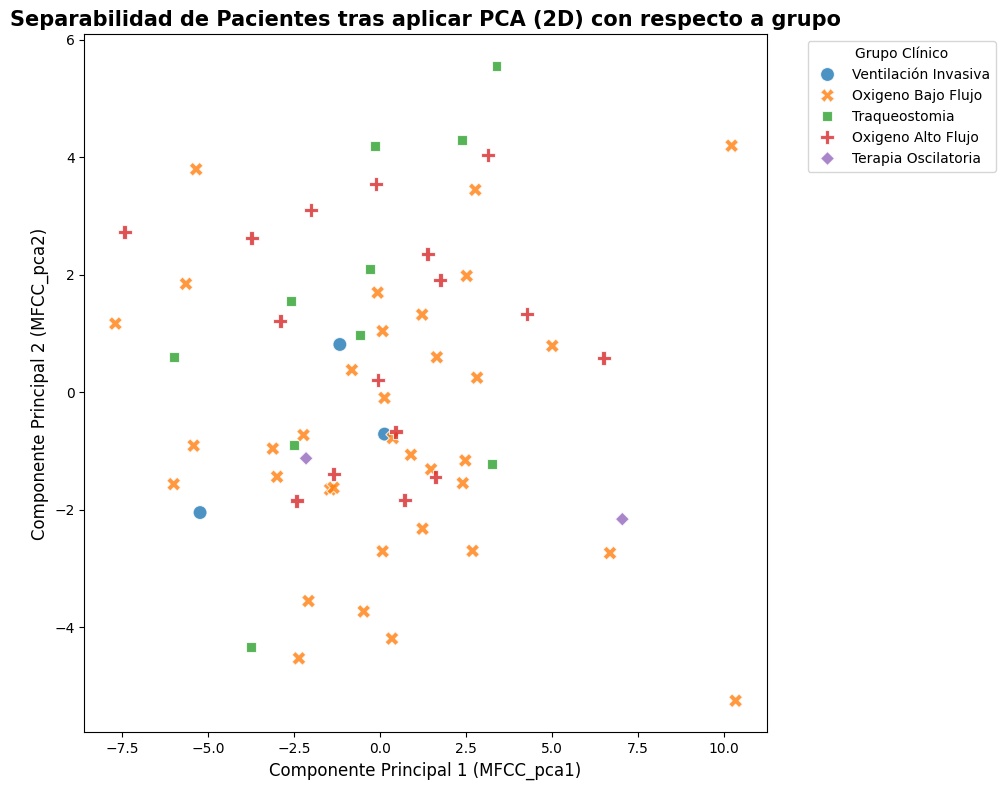

In [35]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros MFCC por que son los que mas información aportan
sns.scatterplot(
    data=df_train_1, 
    x='MFCC_pca1', 
    y='MFCC_pca2', 
    hue='grupo', 
    style='grupo', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')

plt.tight_layout()
plt.show()

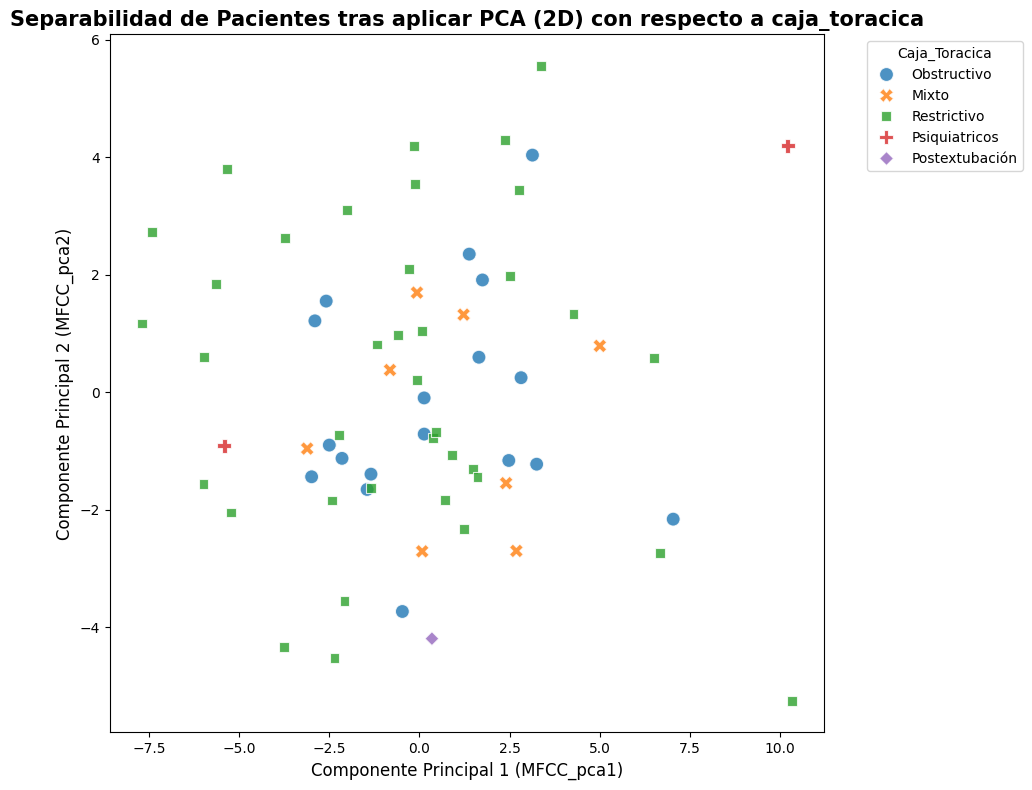

In [37]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros MFCC por que son los que mas información aportan
sns.scatterplot(
    data=df_train_1, 
    x='MFCC_pca1', 
    y='MFCC_pca2', 
    hue='caja_toracica', 
    style='caja_toracica', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Toracica')

plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada paciente como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de MFCC_pca1 y MFCC_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas. No hay correlación verdadera entre los datos y el tipo de enfermedad con este tipo de procesamiento, se trata de una complejidad real. Necesitaremos ver que proyectan los modelos, pero de momento no creemos que se obtengan muy buenos resultados.  

## Entrenamiento Modelos

Para este caso aplicaremos modelos básicos como SVM, RF o GB sobre los datos procesados de MFCC. Como hemos observado, los datos de momento no presentan mucha correlación con respecto al grupo o a la caja_toracica (patología). Esperamos que para este primer análisis no obtener resultados excesivamente excelentes.

In [42]:
from sklearn.metrics import make_scorer
scoring_cv = {
    'accuracy':    make_scorer(accuracy_score),
    'f1_macro':    make_scorer(f1_score, average='macro',    zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
}

columnas_pca = [col for col in df_train_1.columns if 'pca' in col]

X_train_model = df_train_1[columnas_pca]
X_test_model = df_test_1[columnas_pca]

y_train_grupo = df_train_1['grupo']
y_test_grupo = df_test_1['grupo']

y_train_caja = df_train_1['caja_toracica']
y_test_caja = df_test_1['caja_toracica']

#Función común para la evaluación del modelo:
def evaluar_modelo(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv", f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

#### RF

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 55.56% | F1-Score (Macro): 30.00%
CAJA TORÁCICA -> Accuracy: 61.11% | F1-Score (Macro): 26.37%


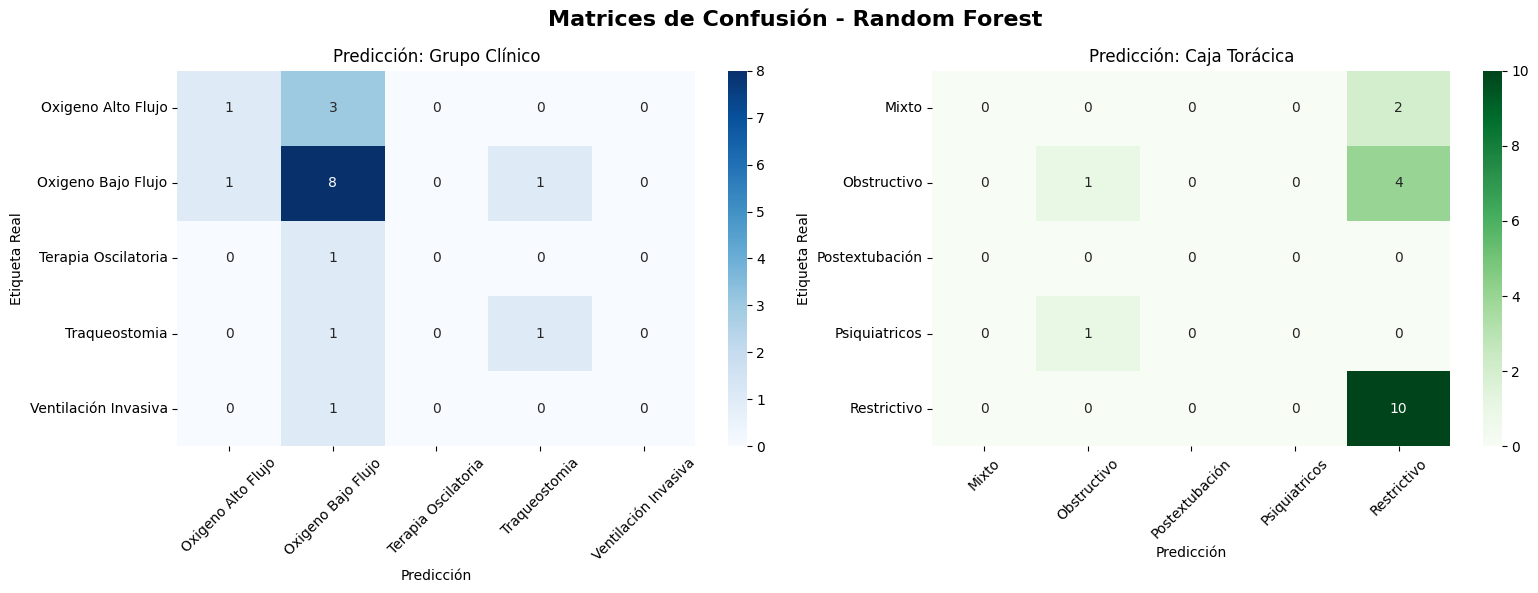

In [47]:
#Tunearemos los hiperparámetros con las ejecuciones y veremos cuales son las mejores configuraciones para cada modelo. Para cada uno haremos que la ejecución inicial sea con 
#hiperparámetros base de la documentación

#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

folds_oficiales = df_train_1['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)
with mlflow.start_run(run_name="RF_ProcesadoBasico_PCA_default"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)

    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)

    evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")
    

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 55.56% | F1-Score (Macro): 30.00%
CAJA TORÁCICA -> Accuracy: 61.11% | F1-Score (Macro): 26.37%


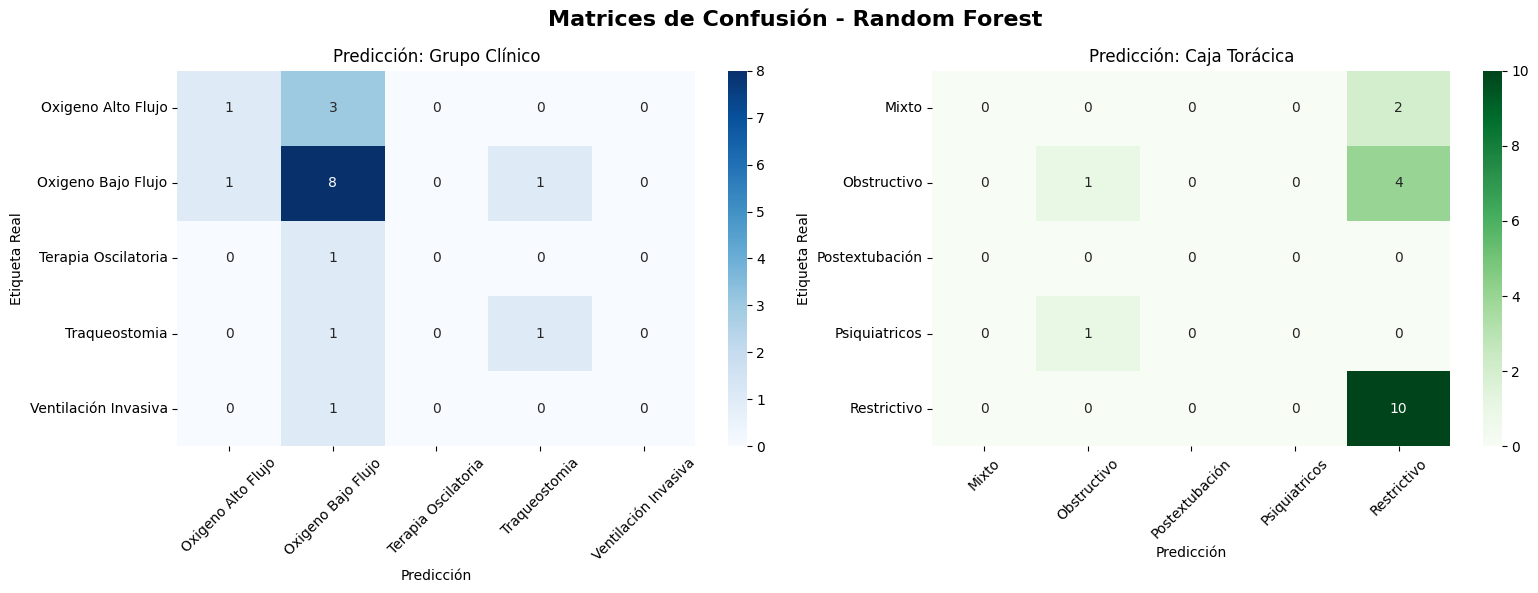

In [57]:
param_grid_rf_1 = {
    'n_estimators': [75, 100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': [1.0,'sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_ProcesadoBasico_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)

    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)

    evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 26.44%
CAJA TORÁCICA -> Accuracy: 61.11% | F1-Score (Macro): 26.37%


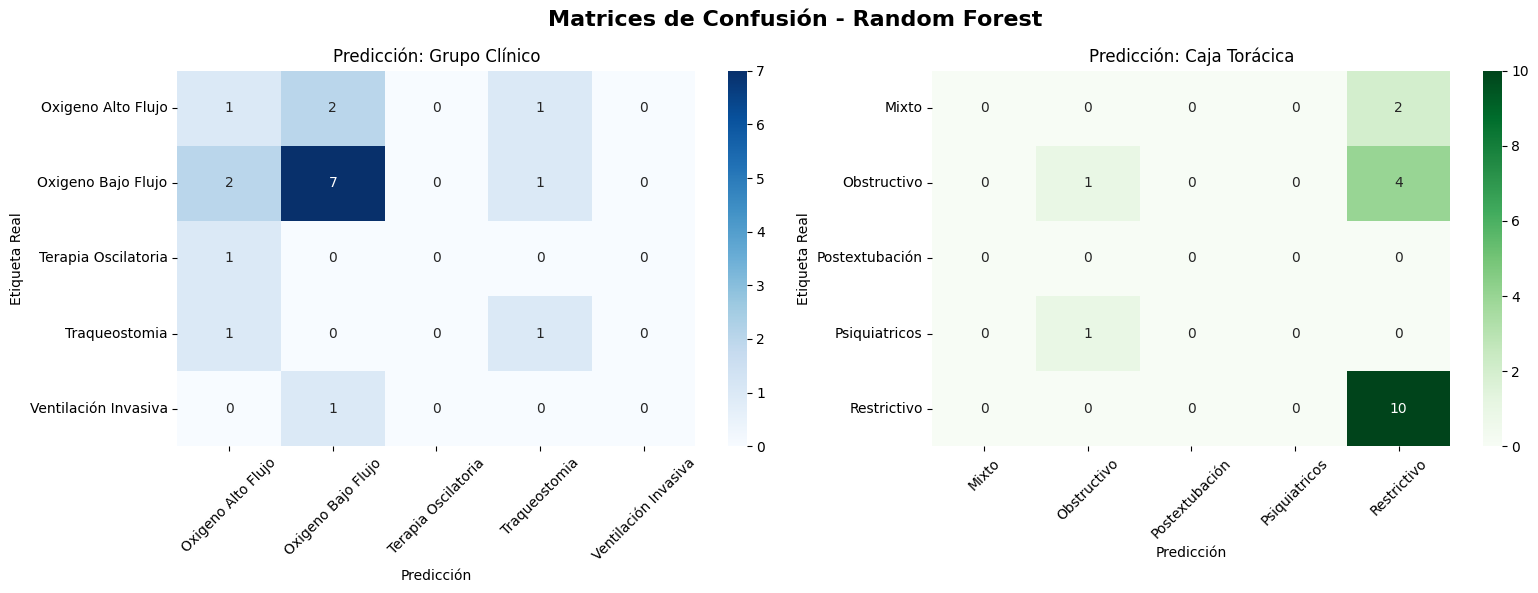

In [58]:
#Segunda configuración de Hiperparámetros.
param_grid_rf_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5, 7],   
    'min_samples_leaf': [1,2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_ProcesadoBasico_PCA_tune2"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)

    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)

    evaluar_modelo(grid_rf_grupo, grid_rf_caja, "Random Forest")

Como podemos observar, el rendimiento no puede mejorar mucho con tuneo de hiperparámetros.

#### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 29.76%
CAJA TORÁCICA -> Accuracy: 55.56% | F1-Score (Macro): 58.06%


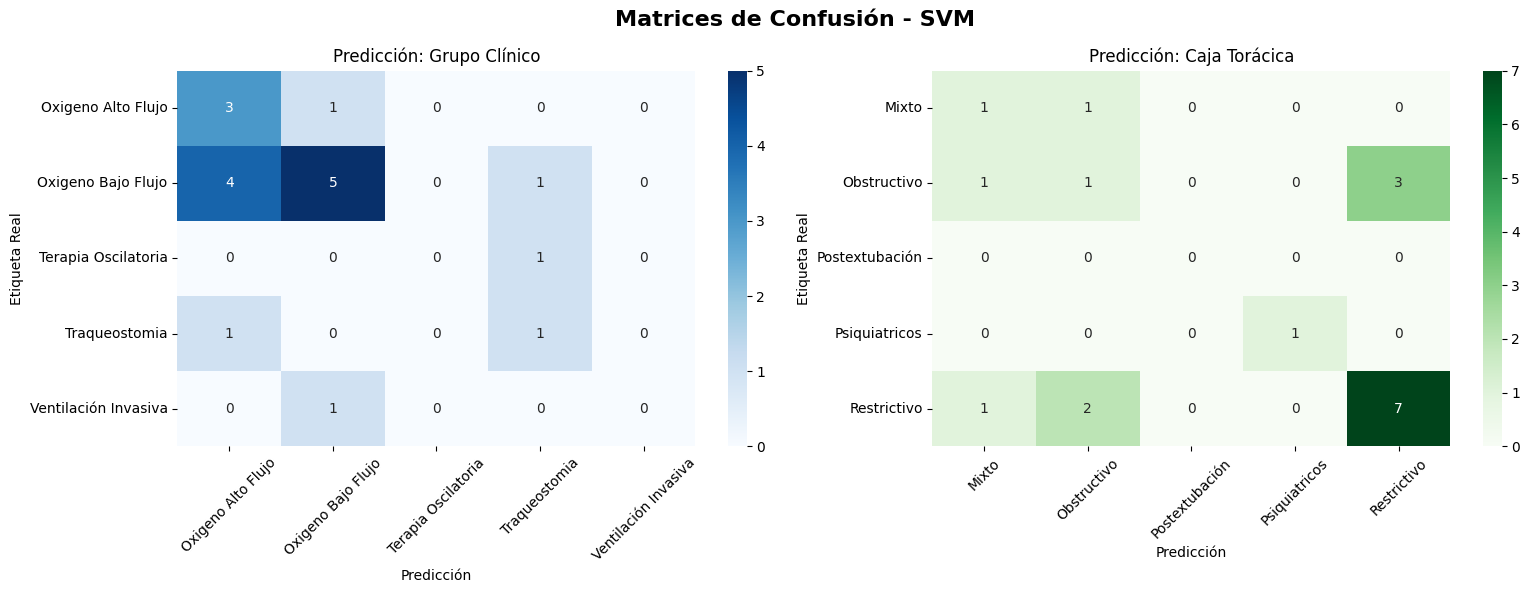

In [61]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="SVM_ProcesadoBasico_PCA_default"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo(grid_svm_grupo, grid_svm_caja, "SVM")


Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 50.00% | F1-Score (Macro): 29.76%
CAJA TORÁCICA -> Accuracy: 55.56% | F1-Score (Macro): 58.06%


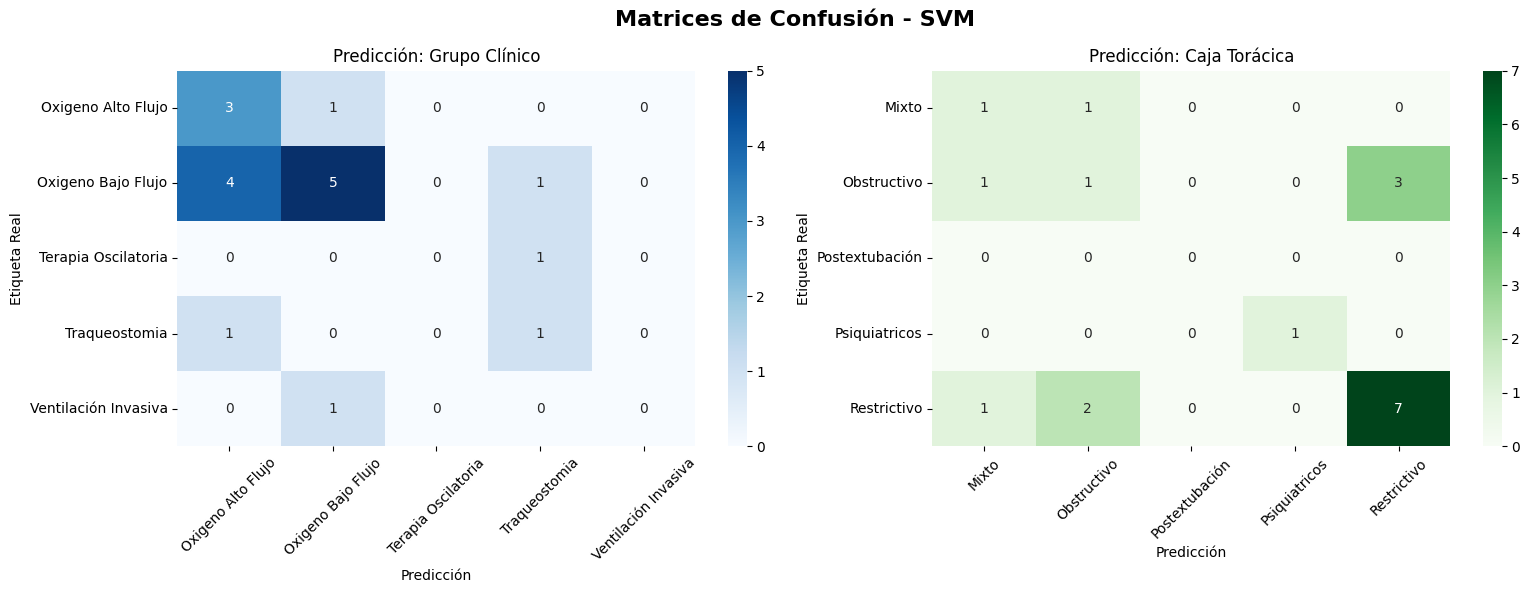

In [65]:
param_grid_svm_1 = {
    'C': [0.5, 1, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_ProcesadoBasico_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo(grid_svm_grupo, grid_svm_caja, "SVM")

En este caso podemos observar que el rendimiento del modelo no puede mejorar mucho más simplemente haciendo tuning de hiperparámetros. 

#### Gradient Boosting

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 38.89% | F1-Score (Macro): 15.87%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 32.61%


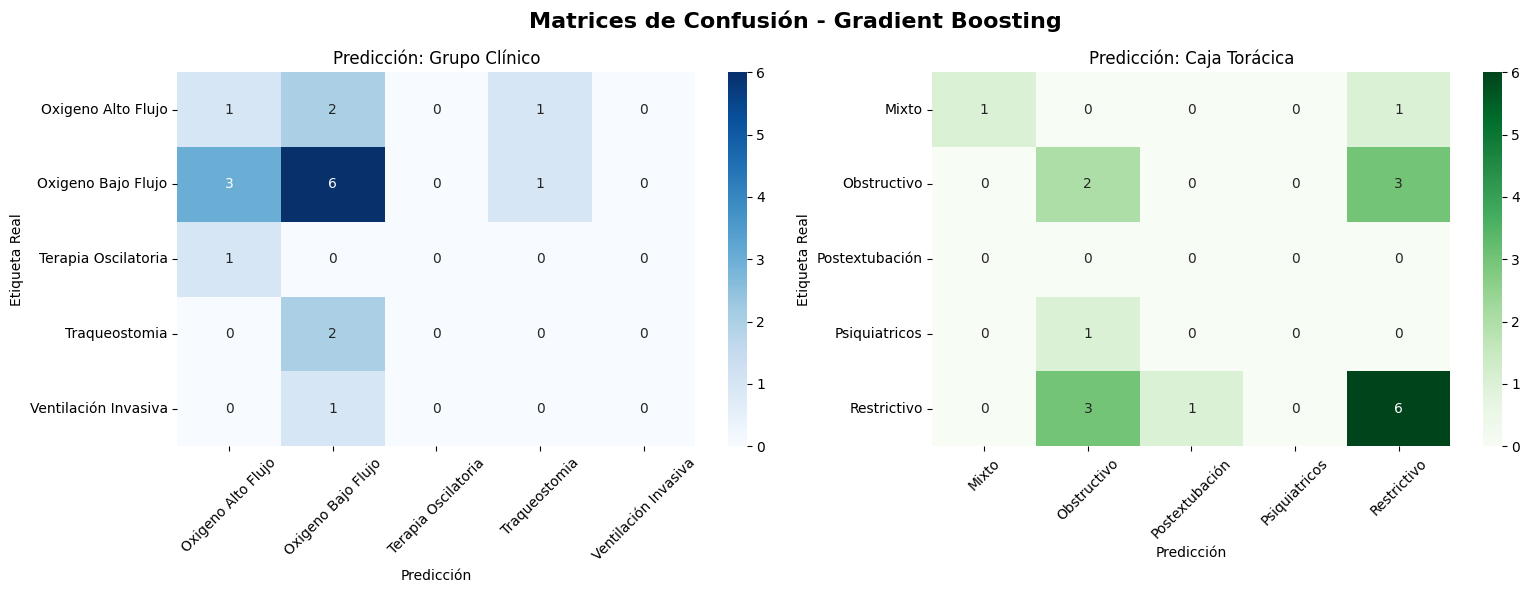

In [69]:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
param_grid_gb = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [2]
}

with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_default"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")    


Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 44.44% | F1-Score (Macro): 23.43%
CAJA TORÁCICA -> Accuracy: 61.11% | F1-Score (Macro): 38.24%


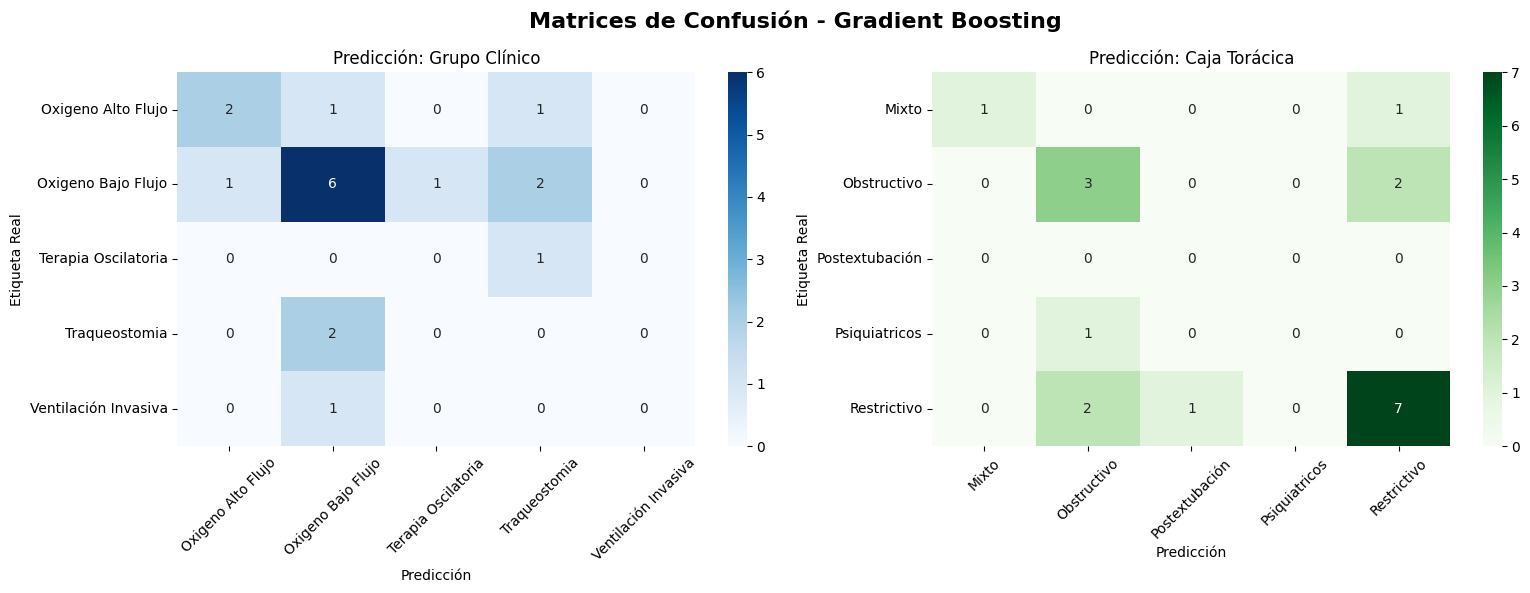

In [71]:
param_grid_gb_1 = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [1,3],
    'min_samples_split': [2, 3]
}

with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_tune1"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")



Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 100}
GRUPOS -> Accuracy: 44.44% | F1-Score (Macro): 20.61%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 32.22%


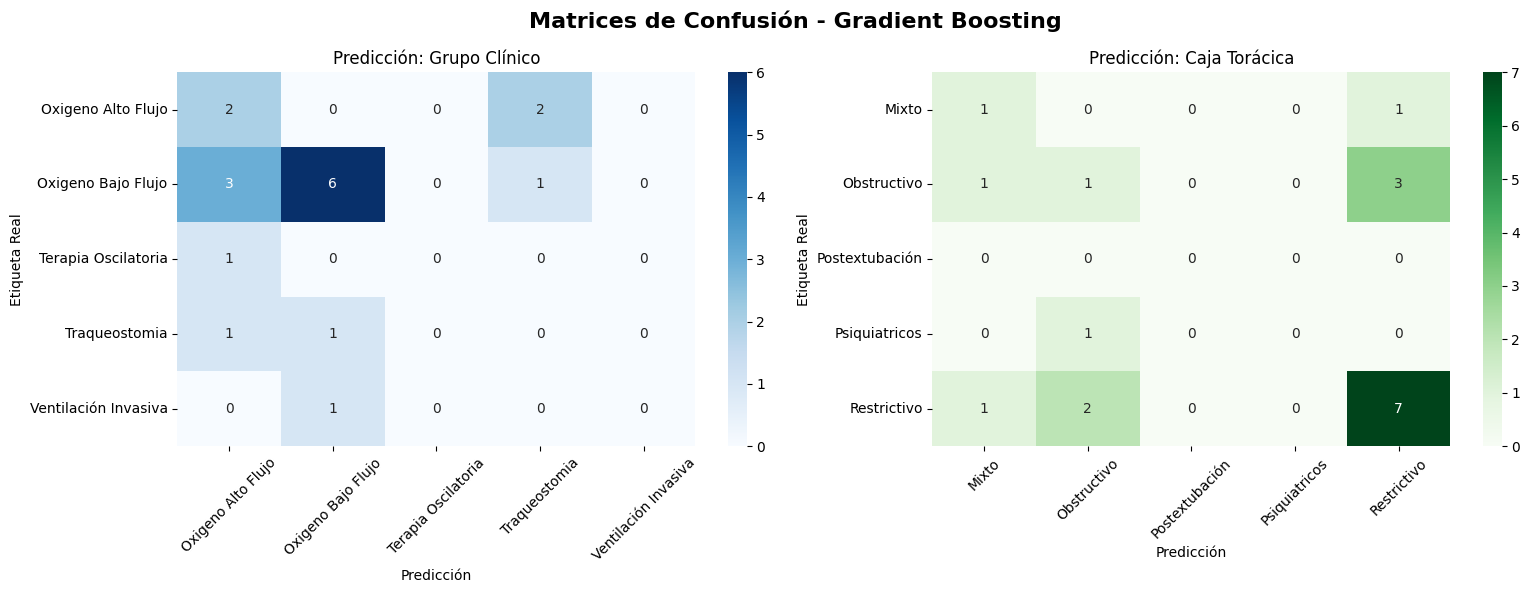

In [73]:
param_grid_gb_2 = {
    'n_estimators': [100, 150],
    'learning_rate': [0.1, 0.15],
    'max_depth': [3,5],
    'min_samples_split': [3, 4]
}

with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_tune2"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Vemos que si utilizamos muchas combinaciones obtenemos un rendimiento peor. Esto se puede deber a un sobreentrenamiento. Para ello cambiaremos el planteamiento en este caso y buscaremos no tener muchas combinaciones para los grids de hiperparámetros.

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 150}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 100}
GRUPOS -> Accuracy: 38.89% | F1-Score (Macro): 15.91%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 29.90%


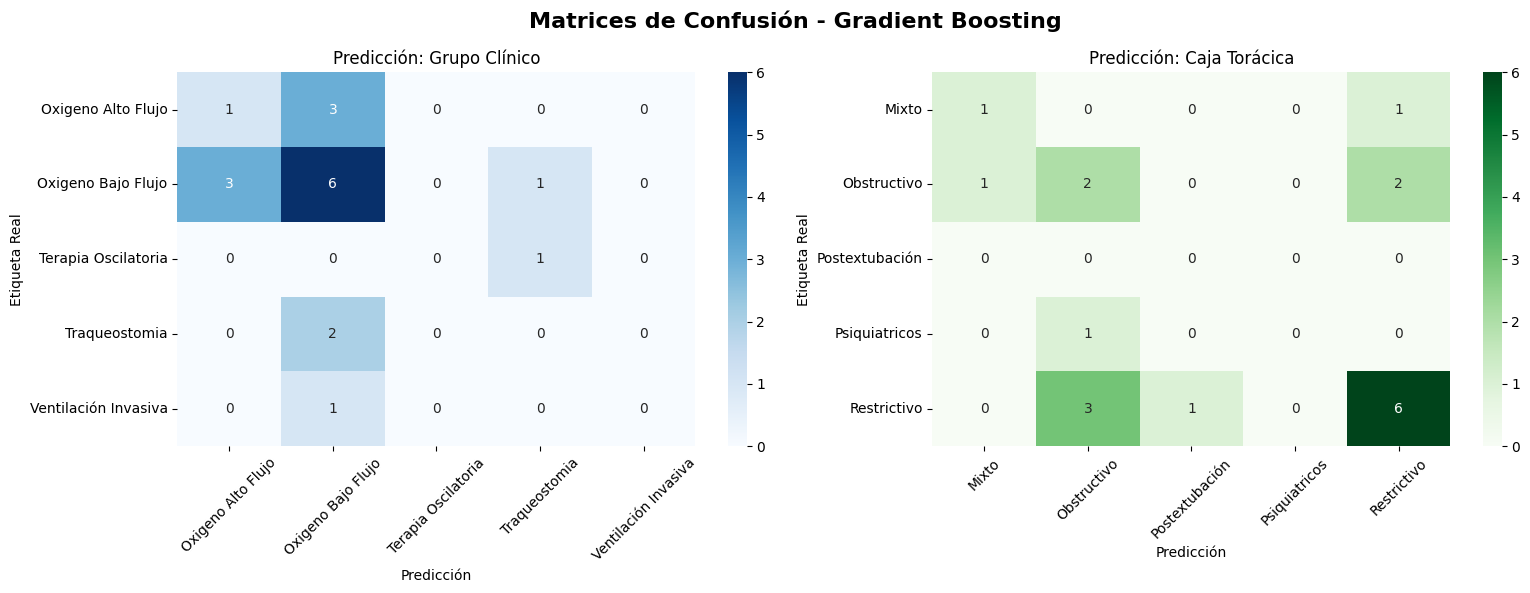

In [76]:
param_grid_gb_3_grupo = {
    'n_estimators': [150, 175],
    'learning_rate': [0.1, 0.15],
    'max_depth': [5, 7],
    'min_samples_split': [4, 6]
}

param_grid_gb_3_caja = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3,5],
    'min_samples_split': [3]
}

with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_tune3"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_3_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_3_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 150}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 6, 'n_estimators': 100}
GRUPOS -> Accuracy: 44.44% | F1-Score (Macro): 19.43%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 32.61%


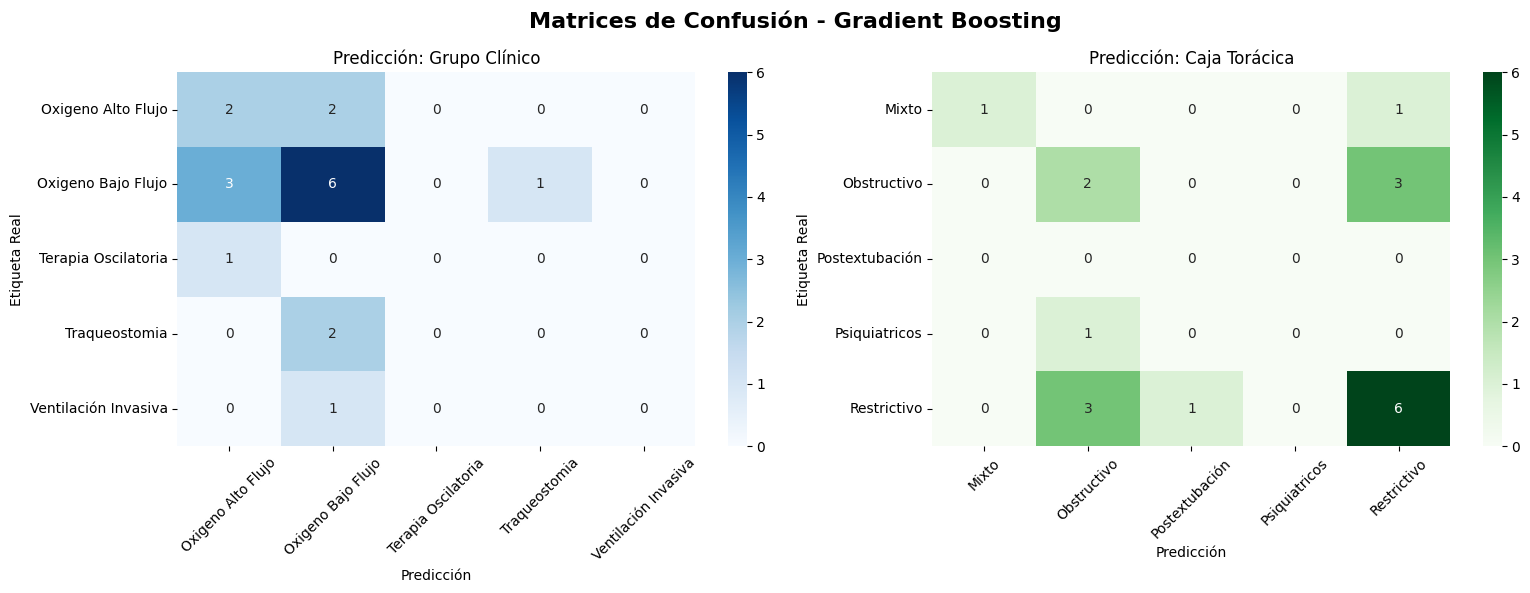

In [77]:
param_grid_gb_4_grupo = {
    'n_estimators': [150],
    'learning_rate': [0.15, 0.2],
    'max_depth': [5],
    'min_samples_split': [6, 7]
}

param_grid_gb_4_caja = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [3, 6]
}


with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_tune4"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_4_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_4_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 6, 'n_estimators': 150}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 8, 'n_estimators': 100}
GRUPOS -> Accuracy: 38.89% | F1-Score (Macro): 15.87%
CAJA TORÁCICA -> Accuracy: 44.44% | F1-Score (Macro): 27.80%


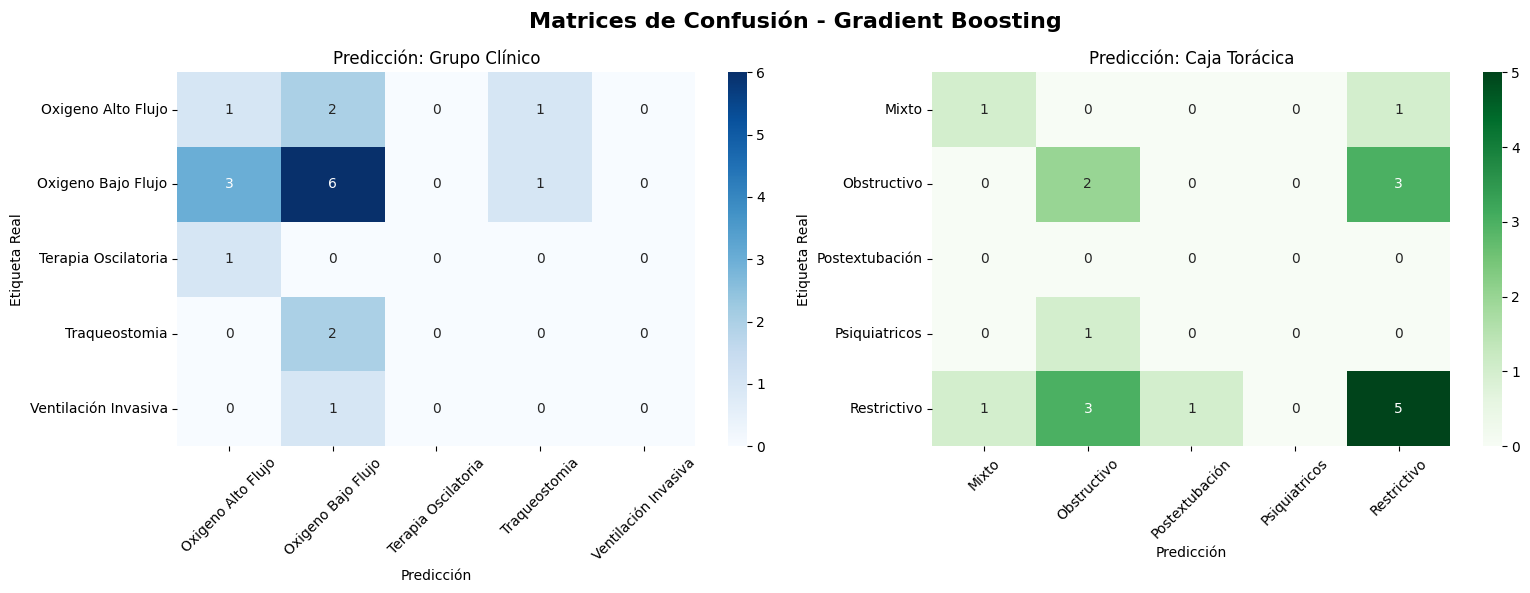

In [80]:
param_grid_gb_5_grupo = {
    'n_estimators': [150],
    'learning_rate': [0.2],
    'max_depth': [5],
    'min_samples_split': [6, 8]
}

param_grid_gb_5_caja = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [6, 8]
}

with mlflow.start_run(run_name="GB_ProcesadoBasico_PCA_tune5"):

    mlflow.set_tag("tipo_dataset", "MFCC_raw") 
    mlflow.set_tag("modelo", "GB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para cada objetivo
    pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
    pesos_caja = compute_sample_weight(class_weight='balanced', y=y_train_caja)
    
    gb_base_grupo = GradientBoostingClassifier(random_state=42)
    grid_gb_grupo = GridSearchCV(gb_base_grupo, param_grid_gb_5_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_grupo.fit(X_train_model, y_train_grupo, **{'sample_weight': pesos_grupo})
    
    gb_base_caja = GradientBoostingClassifier(random_state=42)
    grid_gb_caja = GridSearchCV(gb_base_caja, param_grid_gb_5_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_gb_caja.fit(X_train_model, y_train_caja, **{'sample_weight': pesos_caja})
    
    evaluar_modelo(grid_gb_grupo, grid_gb_caja, "Gradient Boosting")

Con esto podemos observar como ya hemos alcanzado la mejor combinación de hiperparámetros para Gradient Boosting. En general podemos concluir que utilizar MFCC con un preprocesamiento básico, sin chunking y con pooling, no nos lleva a resultados excesivamente esperenzadores. No podemos establecer que sea un fracaso, ya que como hemos dicho, nuestro objetivo es buscar alternativas y probar, sin embargo, para esta alternativa específica, los resultados han sido mediocres, incluso podemos decir que malos. Por ello, buscaremos otros métodos que puedan funcionar mejor.

## Evaluación Final: Test

> Ejecutar estas celdas **una sola vez**, después de decidir qué modelo y preprocesamiento usar basándote en los resultados de CV anteriores.

La función `evaluar_modelo_test` muestra: métricas, classification report, matrices de confusión y curvas AUC-ROC sobre el conjunto de **test**.

In [ ]:
def evaluar_modelo_test(modelo_grupo, modelo_caja, X_test_grupo, X_test_caja,
                        y_test_grupo, y_test_caja, nombre_modelo):
    """
    Evaluación final sobre el conjunto de test (sin validación cruzada).
    - PCA+flat / Pool: pasar el mismo array en X_test_grupo y X_test_caja
    - KBest:           X_test_grupo = X_test_grupo_selected
                       X_test_caja  = X_test_caja_selected
    """
    import numpy as np

    pred_grupo = modelo_grupo.predict(X_test_grupo)
    pred_caja  = modelo_caja.predict(X_test_caja)

    # --- Métricas escalares ---
    acc_g = accuracy_score(y_test_grupo, pred_grupo)
    f1_mg = f1_score(y_test_grupo, pred_grupo, average='macro', zero_division=0)
    f1_wg = f1_score(y_test_grupo, pred_grupo, average='weighted', zero_division=0)
    acc_c = accuracy_score(y_test_caja,  pred_caja)
    f1_mc = f1_score(y_test_caja,  pred_caja,  average='macro', zero_division=0)
    f1_wc = f1_score(y_test_caja,  pred_caja,  average='weighted', zero_division=0)
    print(f"[TEST] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mg*100:.2f}% | F1-Weighted: {f1_wg*100:.2f}%")
    print(f"[TEST] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mc*100:.2f}% | F1-Weighted: {f1_wc*100:.2f}%")

    # --- Classification reports ---
    print("\n--- Classification Report: Grupo ---")
    print(classification_report(y_test_grupo, pred_grupo, zero_division=0))
    print("\n--- Classification Report: Caja Torácica ---")
    print(classification_report(y_test_caja, pred_caja, zero_division=0))

    # --- Matrices de confusión ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión [TEST] - {nombre_modelo}', fontsize=14, fontweight='bold')
    cm_g = confusion_matrix(y_test_grupo, pred_grupo)
    sns.heatmap(cm_g, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Grupo Clínico')
    axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)
    cm_c = confusion_matrix(y_test_caja, pred_caja)
    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('Caja Torácica')
    axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # --- AUC-ROC ---
    clases_g = np.unique(y_test_grupo)
    clases_c = np.unique(y_test_caja)
    y_score_g = modelo_grupo.predict_proba(X_test_grupo)
    y_score_c = modelo_caja.predict_proba(X_test_caja)
    y_bin_g = label_binarize(y_test_grupo, classes=clases_g)
    y_bin_c = label_binarize(y_test_caja,  classes=clases_c)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'AUC-ROC [TEST] - {nombre_modelo}', fontsize=14, fontweight='bold')
    for i, cls in enumerate(clases_g):
        fpr, tpr, _ = roc_curve(y_bin_g[:, i], y_score_g[:, i])
        axes[0].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title('Grupo Clínico'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].legend(fontsize=8)
    for i, cls in enumerate(clases_c):
        fpr, tpr, _ = roc_curve(y_bin_c[:, i], y_score_c[:, i])
        axes[1].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title('Caja Torácica'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# TEST FINAL: Random Forest
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_rf = X_train_model,         X_test_rf = X_test_model  (mismo para grupo y caja)

X_train_rf_grupo = ...  # ← COMPLETAR
X_test_rf_grupo  = ...  # ← COMPLETAR
X_train_rf_caja  = ...  # ← COMPLETAR (puede ser igual a X_train_rf_grupo si no es KBest)
X_test_rf_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
modelo_rf_grupo = RandomForestClassifier(
    n_estimators=...,       # ← COMPLETAR
    max_depth=...,          # ← COMPLETAR
    min_samples_split=...,  # ← COMPLETAR
    random_state=42
)
modelo_rf_caja = RandomForestClassifier(
    n_estimators=...,       # ← COMPLETAR
    max_depth=...,          # ← COMPLETAR
    min_samples_split=...,  # ← COMPLETAR
    random_state=42
)

modelo_rf_grupo.fit(X_train_rf_grupo, y_train_grupo)
modelo_rf_caja.fit(X_train_rf_caja,   y_train_caja)

evaluar_modelo_test(modelo_rf_grupo, modelo_rf_caja,
                    X_test_rf_grupo, X_test_rf_caja,
                    y_test_grupo, y_test_caja,
                    "RF_Test_Final")

In [ ]:
# =========================================================
# TEST FINAL: SVM
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_svm = X_train_model,         X_test_svm = X_test_model

X_train_svm_grupo = ...  # ← COMPLETAR
X_test_svm_grupo  = ...  # ← COMPLETAR
X_train_svm_caja  = ...  # ← COMPLETAR
X_test_svm_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
# Nota: SVC(probability=True) es necesario para AUC-ROC con predict_proba
modelo_svm_grupo = SVC(
    C=...,        # ← COMPLETAR
    kernel=...,   # ← COMPLETAR  p.ej. 'rbf'
    gamma=...,    # ← COMPLETAR  p.ej. 'scale'
    probability=True,
    random_state=42
)
modelo_svm_caja = SVC(
    C=...,        # ← COMPLETAR
    kernel=...,   # ← COMPLETAR
    gamma=...,    # ← COMPLETAR
    probability=True,
    random_state=42
)

modelo_svm_grupo.fit(X_train_svm_grupo, y_train_grupo)
modelo_svm_caja.fit(X_train_svm_caja,   y_train_caja)

evaluar_modelo_test(modelo_svm_grupo, modelo_svm_caja,
                    X_test_svm_grupo, X_test_svm_caja,
                    y_test_grupo, y_test_caja,
                    "SVM_Test_Final")

In [ ]:
# =========================================================
# TEST FINAL: Gradient Boosting
# Solo PCA+flat disponible en este notebook
# =========================================================

X_train_gb_grupo = X_train_model  # PCA+flat
X_test_gb_grupo  = X_test_model
X_train_gb_caja  = X_train_model
X_test_gb_caja   = X_test_model

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
pesos_grupo = compute_sample_weight(class_weight='balanced', y=y_train_grupo)
pesos_caja  = compute_sample_weight(class_weight='balanced', y=y_train_caja)

modelo_gb_grupo = GradientBoostingClassifier(
    n_estimators=...,    # ← COMPLETAR
    learning_rate=...,   # ← COMPLETAR
    max_depth=...,       # ← COMPLETAR
    min_samples_split=...,
    random_state=42
)
modelo_gb_caja = GradientBoostingClassifier(
    n_estimators=...,    # ← COMPLETAR
    learning_rate=...,   # ← COMPLETAR
    max_depth=...,       # ← COMPLETAR
    min_samples_split=...,
    random_state=42
)

modelo_gb_grupo.fit(X_train_gb_grupo, y_train_grupo, sample_weight=pesos_grupo)
modelo_gb_caja.fit(X_train_gb_caja,   y_train_caja,  sample_weight=pesos_caja)

evaluar_modelo_test(modelo_gb_grupo, modelo_gb_caja,
                    X_test_gb_grupo, X_test_gb_caja,
                    y_test_grupo, y_test_caja,
                    "GB_Test_Final")